# Lab 2 — Data Visualization and Time Series Analysis

**Student:** Lavoisier MUKAM

This notebook contains my work for Lab 2 on:
- visualization with `matplotlib`
- interactive visualization with `plotly`
- data aggregation with `pandas`
- time series analysis with `DateTimeIndex`

## Imports

In [1]:
import zipfile
import urllib.request
from os import path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Part 1 — Visualization with `matplotlib`

## 1. Plot the functions $x \mapsto x^d$ on $[-1, 2]$ for $d \in \{2, 3, 4\}$

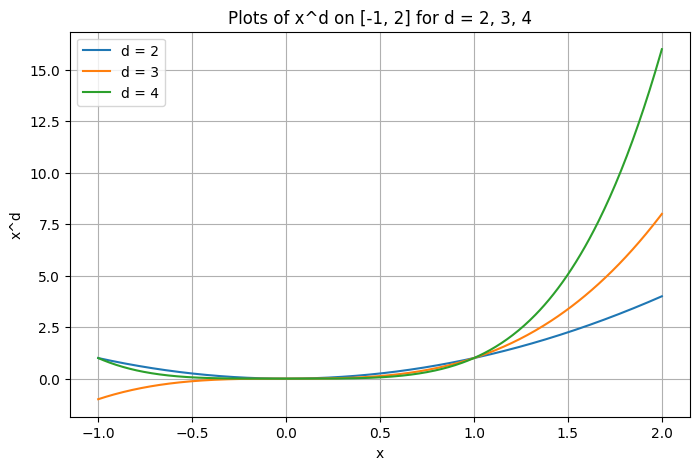

In [2]:
x = np.linspace(-1, 2, 500)

plt.figure(figsize=(8, 5))
for d in [2, 3, 4]:
    plt.plot(x, x**d, label=f"d = {d}")

plt.xlabel("x")
plt.ylabel("x^d")
plt.title("Plots of x^d on [-1, 2] for d = 2, 3, 4")
plt.legend()
plt.grid(True)
plt.show()

## 2. Export the plot

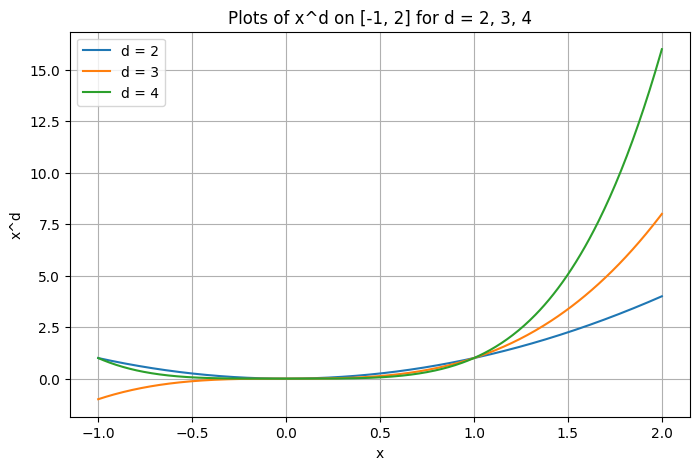

In [3]:
x = np.linspace(-1, 2, 500)

plt.figure(figsize=(8, 5))
for d in [2, 3, 4]:
    plt.plot(x, x**d, label=f"d = {d}")

plt.xlabel("x")
plt.ylabel("x^d")
plt.title("Plots of x^d on [-1, 2] for d = 2, 3, 4")
plt.legend()
plt.grid(True)

plt.savefig("powers_plot.png")
plt.savefig("powers_plot_highres.png", dpi=300)
plt.savefig("powers_plot.pdf")
plt.show()

For scientific figures, `.pdf` is usually preferable because it is vector-based and keeps a high quality when zooming or printing.  
`.png` is convenient for web display and quick sharing, but it depends on the chosen resolution.

## Bonus — Two y-axes on the same figure

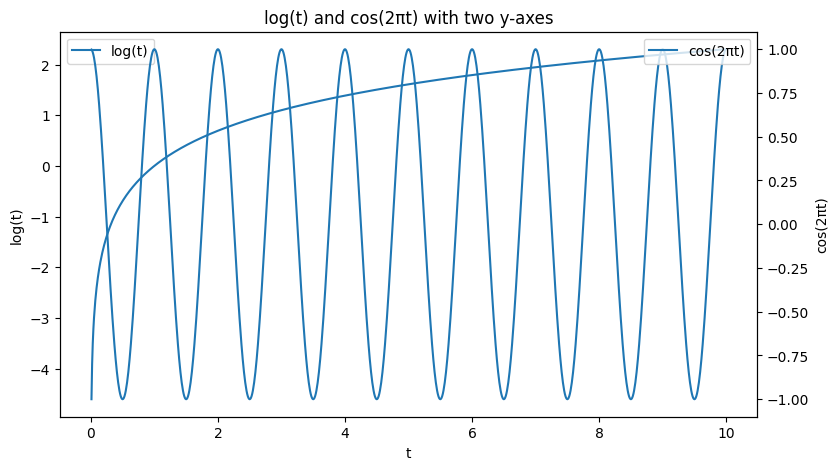

In [4]:
t = np.arange(0.01, 10.0, 0.01)
data1 = np.log(t)
data2 = np.cos(2 * np.pi * t)

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(t, data1, label="log(t)")
ax1.set_xlabel("t")
ax1.set_ylabel("log(t)")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(t, data2, label="cos(2πt)")
ax2.set_ylabel("cos(2πt)")
ax2.legend(loc="upper right")

plt.title("log(t) and cos(2πt) with two y-axes")
plt.show()

## Bonus — Figure layout examples

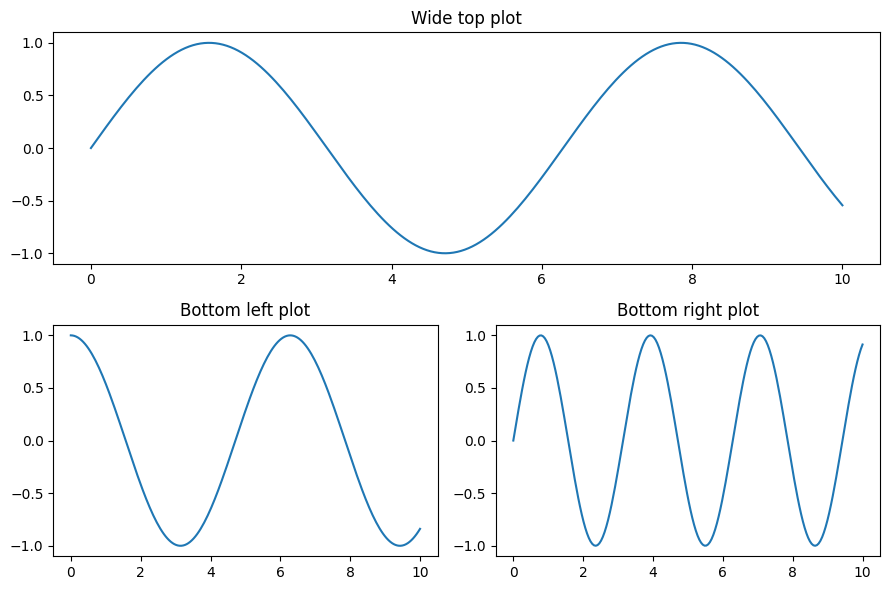

In [5]:
x = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(2 * x)

fig = plt.figure(figsize=(9, 6))

ax_top = plt.subplot(2, 2, (1, 2))
ax_bottom_left = plt.subplot(2, 2, 3)
ax_bottom_right = plt.subplot(2, 2, 4)

ax_top.plot(x, y1)
ax_bottom_left.plot(x, y2)
ax_bottom_right.plot(x, y3)

ax_top.set_title("Wide top plot")
ax_bottom_left.set_title("Bottom left plot")
ax_bottom_right.set_title("Bottom right plot")

plt.tight_layout()
plt.show()

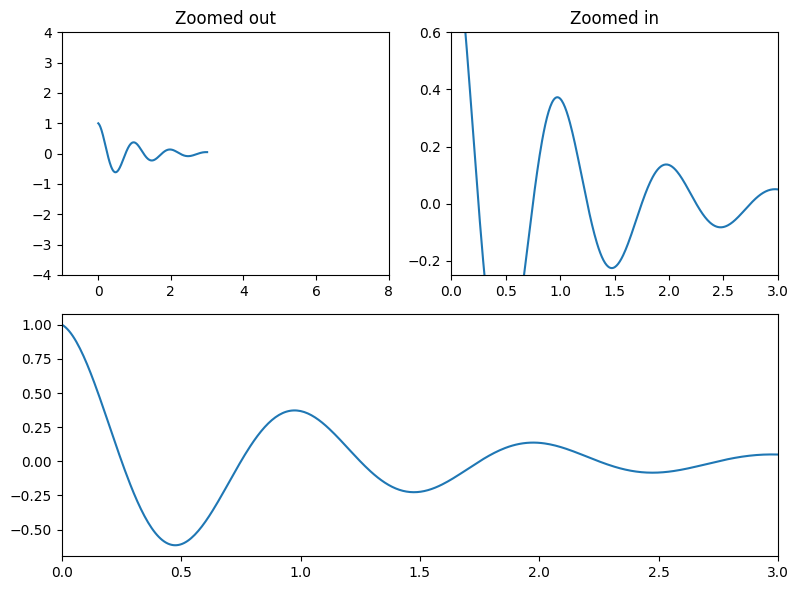

In [6]:
x = np.linspace(0, 3, 400)
y = np.exp(-x) * np.cos(2 * np.pi * x)

fig = plt.figure(figsize=(8, 6))

ax_top_left = plt.subplot(2, 2, 1)
ax_top_right = plt.subplot(2, 2, 2)
ax_bottom = plt.subplot(2, 2, (3, 4))

ax_top_left.plot(x, y)
ax_top_left.set_title("Zoomed out")
ax_top_left.set_xlim(-1, 8)
ax_top_left.set_ylim(-4, 4)

ax_top_right.plot(x, y)
ax_top_right.set_title("Zoomed in")
ax_top_right.set_xlim(0, 3)
ax_top_right.set_ylim(-0.25, 0.6)

ax_bottom.plot(x, y)
ax_bottom.set_xlim(0, 3)

plt.tight_layout()
plt.show()

# Part 2 — Visualization with `plotly`

## 1. Load the NYC taxi dataset

This section assumes that `nyc_taxi.csv` is available in the current working directory.

In [7]:
df = pd.read_csv(
    "nyc_taxi.csv",
    parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"],
    index_col="tpep_pickup_datetime",
)

print(df.head())
print(df.shape)
print(df.index[:5])

                      VendorID tpep_dropoff_datetime  passenger_count  \
tpep_pickup_datetime                                                    
2015-01-15 19:05:39          2   2015-01-15 19:23:42                1   
2015-01-10 20:33:38          1   2015-01-10 20:53:28                1   
2015-01-10 20:33:38          1   2015-01-10 20:43:41                1   
2015-01-10 20:33:39          1   2015-01-10 20:35:31                1   
2015-01-10 20:33:39          1   2015-01-10 20:52:58                1   

                      trip_distance  pickup_longitude  pickup_latitude  \
tpep_pickup_datetime                                                     
2015-01-15 19:05:39            1.59        -73.993896        40.750111   
2015-01-10 20:33:38            3.30        -74.001648        40.724243   
2015-01-10 20:33:38            1.80        -73.963341        40.802788   
2015-01-10 20:33:39            0.50        -74.009087        40.713818   
2015-01-10 20:33:39            3.00        -

## 2. Extract temporal information

In [8]:
df["month"] = df.index.month
df["day"] = df.index.day
df["weekday"] = df.index.dayofweek
df["hour"] = df.index.hour
df["date"] = df.index.date

day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

df["weekday_name"] = df["weekday"].map(day_names)

print(df[["month", "day", "weekday", "hour", "date", "weekday_name"]].head())

                      month  day  weekday  hour        date weekday_name
tpep_pickup_datetime                                                    
2015-01-15 19:05:39       1   15        3    19  2015-01-15     Thursday
2015-01-10 20:33:38       1   10        5    20  2015-01-10     Saturday
2015-01-10 20:33:38       1   10        5    20  2015-01-10     Saturday
2015-01-10 20:33:39       1   10        5    20  2015-01-10     Saturday
2015-01-10 20:33:39       1   10        5    20  2015-01-10     Saturday


## 3. Average trip counts per hour for each day of the week

In [9]:
trip_counts = (
    df.groupby(["date", "weekday_name", "hour"])
      .size()
      .reset_index(name="trip_count")
)

avg_trip_counts = (
    trip_counts.groupby(["weekday_name", "hour"])["trip_count"]
    .mean()
    .reset_index()
)

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

avg_trip_counts["weekday_name"] = pd.Categorical(
    avg_trip_counts["weekday_name"],
    categories=weekday_order,
    ordered=True
)

avg_trip_counts = avg_trip_counts.sort_values(["weekday_name", "hour"])

fig = px.line(
    avg_trip_counts,
    x="hour",
    y="trip_count",
    color="weekday_name",
    title="Average trip counts per hour for each day of the week",
    labels={
        "hour": "Hour of day",
        "trip_count": "Average number of trips",
        "weekday_name": "Day of week",
    }
)

fig.show()

## 4. Day with the highest average number of trips at 7am

In [10]:
at_7am = avg_trip_counts[avg_trip_counts["hour"] == 7]
best_day_7am = at_7am.loc[at_7am["trip_count"].idxmax()]

print(at_7am)
print("\nBest day at 7am:", best_day_7am["weekday_name"])

    weekday_name  hour  trip_count
31        Monday     7      174.25
125      Tuesday     7       87.50
149    Wednesday     7      211.75
103     Thursday     7      211.60
7         Friday     7      177.60
55      Saturday     7       44.00
79        Sunday     7       44.00

Best day at 7am: Wednesday


## 5. Animation of the average fare amount per day

In [11]:
df_agg = df.groupby(["day"])["fare_amount"].mean().reset_index()
print(df_agg.head())

   day  fare_amount
0    1    13.130599
1    2    11.996683
2    3    11.599003
3    4    12.869905
4    5    12.343922


In [12]:
df_anim = df_agg.copy()
df_anim["frame"] = df_anim["day"]

fig = px.scatter(
    df_anim,
    x="day",
    y="fare_amount",
    animation_frame="frame",
    range_x=[df_anim["day"].min(), df_anim["day"].max()],
    range_y=[df_anim["fare_amount"].min(), df_anim["fare_amount"].max() * 1.1],
    title="Animation of the average fare amount per day",
    labels={
        "day": "Day of month",
        "fare_amount": "Average fare amount",
    }
)

fig.show()

# Part 3 — Time Series Analysis with `pandas`

## 1. Load the household power consumption dataset

In [13]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/"
filename = "household_power_consumption"
zipfilename = filename + ".zip"
location = url + zipfilename

if not path.isfile(zipfilename):
    urllib.request.urlretrieve(location, zipfilename)

zipfile.ZipFile(zipfilename).extractall()

na_values = ["?", ""]
fields = ["Date", "Time", "Global_active_power"]

df_power = pd.read_csv(
    filename + ".txt",
    sep=";",
    nrows=200_000,
    na_values=na_values,
    usecols=fields
)

print(df_power.head())
print(df_power.shape)
print(df_power.info())

         Date      Time  Global_active_power
0  16/12/2006  17:24:00                4.216
1  16/12/2006  17:25:00                5.360
2  16/12/2006  17:26:00                5.374
3  16/12/2006  17:27:00                5.388
4  16/12/2006  17:28:00                3.666
(200000, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 200000 non-null  object 
 1   Time                 200000 non-null  object 
 2   Global_active_power  196268 non-null  float64
dtypes: float64(1), object(2)
memory usage: 4.6+ MB
None


## 2. Count and remove missing rows

In [14]:
n_missing_rows = df_power.isna().any(axis=1).sum()
print("Number of rows with missing values:", n_missing_rows)

df_power = df_power.dropna()

print(df_power.shape)
print(df_power.isna().sum())

Number of rows with missing values: 3732
(196268, 3)
Date                   0
Time                   0
Global_active_power    0
dtype: int64


## 3. Create a `DateTimeIndex`

In [15]:
df_power["DateTime"] = pd.to_datetime(
    df_power["Date"] + " " + df_power["Time"],
    dayfirst=True
)

df_power = df_power.set_index("DateTime")
df_power["Global_active_power"] = pd.to_numeric(df_power["Global_active_power"])

print(df_power.head())
print(type(df_power.index))
print(df_power["Global_active_power"].dtype)

                           Date      Time  Global_active_power
DateTime                                                      
2006-12-16 17:24:00  16/12/2006  17:24:00                4.216
2006-12-16 17:25:00  16/12/2006  17:25:00                5.360
2006-12-16 17:26:00  16/12/2006  17:26:00                5.374
2006-12-16 17:27:00  16/12/2006  17:27:00                5.388
2006-12-16 17:28:00  16/12/2006  17:28:00                3.666
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
float64


A `DateTimeIndex` makes time series manipulation much easier. It allows easy date-based filtering, resampling, aggregation by day/week/month, and better plotting of temporal data.

## 4. Daily averages from 2007-01-01 to 2007-04-30

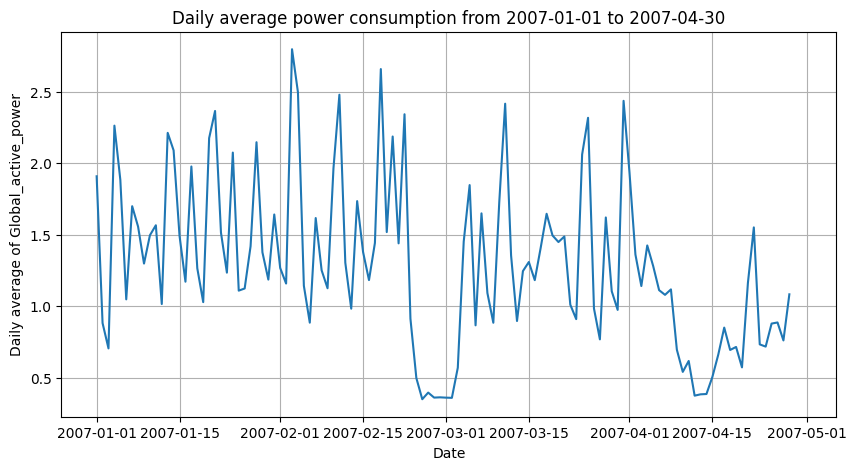

In [16]:
daily_avg = df_power["Global_active_power"].resample("D").mean()
daily_avg_period = daily_avg.loc["2007-01-01":"2007-04-30"]

plt.figure(figsize=(10, 5))
plt.plot(daily_avg_period.index, daily_avg_period.values)
plt.xlabel("Date")
plt.ylabel("Daily average of Global_active_power")
plt.title("Daily average power consumption from 2007-01-01 to 2007-04-30")
plt.grid(True)
plt.show()

A plausible explanation is the transition from winter to early spring. As temperatures become milder, heating needs decrease, which may reduce household electricity consumption. Daily habits and occupancy patterns may also contribute to the observed variations.

# Part 4 — Adding Temperature Information

This section assumes that the file `TG_STAID011249.txt` is available locally.  
Depending on the exact file format, the value of `skiprows` may need to be adjusted.

## 1. Load and clean the temperature dataset

In [17]:
temp_df = pd.read_csv(
    "TG_STAID011249.txt",
    sep=",",
    skiprows=20
)

print(temp_df.head())
print(temp_df.columns)

   STAID   SOUID      DATE     TG   Q_TG
0  11249   71642  19210301     50      0
1  11249   71642  19210302     46      0
2  11249   71642  19210303     46      0
3  11249   71642  19210304     31      0
4  11249   71642  19210305     95      0
Index(['STAID', ' SOUID', '    DATE', '   TG', ' Q_TG'], dtype='object')


In [18]:
temp_df.columns = temp_df.columns.str.strip()
temp_df = temp_df[["DATE", "TG"]]

temp_df["TG"] = temp_df["TG"].replace(-9999, np.nan)
temp_df["TG"] = temp_df["TG"] / 10
temp_df["DATE"] = pd.to_datetime(temp_df["DATE"], format="%Y%m%d")
temp_df = temp_df.set_index("DATE")

print(temp_df.head())
print(type(temp_df.index))

             TG
DATE           
1921-03-01  5.0
1921-03-02  4.6
1921-03-03  4.6
1921-03-04  3.1
1921-03-05  9.5
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


## 2. Restrict the temperature series to 2007-01-01 / 2007-04-30

In [19]:
temp_period = temp_df.loc["2007-01-01":"2007-04-30", "TG"]

print(temp_period.head())
print(temp_period.tail())

DATE
2007-01-01     9.6
2007-01-02     6.0
2007-01-03     6.1
2007-01-04     9.2
2007-01-05    10.0
Name: TG, dtype: float64
DATE
2007-04-26    19.2
2007-04-27    20.0
2007-04-28    20.0
2007-04-29    19.0
2007-04-30    16.9
Name: TG, dtype: float64


## 3. Plot temperature and power consumption on the same figure

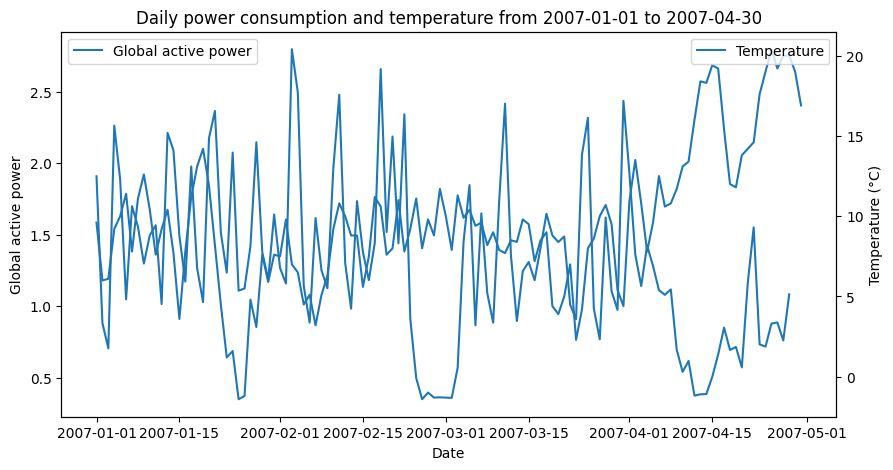

In [20]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(daily_avg_period.index, daily_avg_period.values, label="Global active power")
ax1.set_xlabel("Date")
ax1.set_ylabel("Global active power")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(temp_period.index, temp_period.values, label="Temperature")
ax2.set_ylabel("Temperature (°C)")
ax2.legend(loc="upper right")

plt.title("Daily power consumption and temperature from 2007-01-01 to 2007-04-30")
plt.show()

The two time series suggest a negative relationship: as temperature increases from winter to spring, average household power consumption tends to decrease, which is consistent with lower heating needs.

# Conclusion

In this lab, I practiced:
- plotting with `matplotlib`
- interactive visualization with `plotly`
- grouping and aggregation with `pandas`
- building and using a `DateTimeIndex`
- comparing two aligned time series with different scales